In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(models, top_n=20):
    """
    Plots the top N most important features for each model in the dictionary.
    """
    for target, model in models.items():
        # Create a DataFrame of feature importances
        # LGBMClassifier stores feature names in .feature_name_ when trained on a DataFrame
        fi_df = pd.DataFrame({
            'feature': model.feature_name_,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        # Display text summary
        print(f"\n=== Top 10 Features for {target} ===")
        print(fi_df.head(10))
        
        # Plot
        plt.figure(figsize=(10, 8))
        sns.barplot(data=fi_df.head(top_n), x='importance', y='feature', palette='viridis')
        plt.title(f'Feature Importance: {target}')
        plt.xlabel('Importance (Split)')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()

# Usage example:
# from src.modeling_lgbm import load_final_models
# models = load_final_models()
# plot_feature_importance(models)

In [9]:
import sys
from pathlib import Path

# Detect project root (parent of notebooks/)
ROOT = Path.cwd().parents[0]

# Define paths used in the pipeline
DATA_TRAIN   = ROOT / "data" / "processed" / "training_fe_full.csv"
DATA_LABELS  = ROOT / "data" / "raw" / "training_set_labels.csv"
DATA_TEST    = ROOT / "data" / "processed" / "test_fe_full.csv"

ARTIFACTS    = ROOT / "artifacts_lgbm"

ROOT = Path.cwd().parents[0]
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

In [5]:
from src.modeling_lgbm import load_final_models

In [10]:
models = load_final_models(str(ARTIFACTS))


=== Top 10 Features for h1n1_vaccine ===
                                      feature  importance
66                              PVASxPBI_h1n1         408
49        employment_industry_te_h1n1_vaccine         407
51      employment_occupation_te_h1n1_vaccine         363
15                          opinion_h1n1_risk         324
52  employment_occupation_te_seasonal_vaccine         308
14                opinion_h1n1_vacc_effective         298
55                                  PVAS_seas         284
50    employment_industry_te_seasonal_vaccine         265
20                                  age_group         264
54                                  PVAS_h1n1         253


C:\Users\samak\AppData\Local\Temp\ipykernel_29612\1099630203.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(top_n), x='importance', y='feature', palette='viridis')


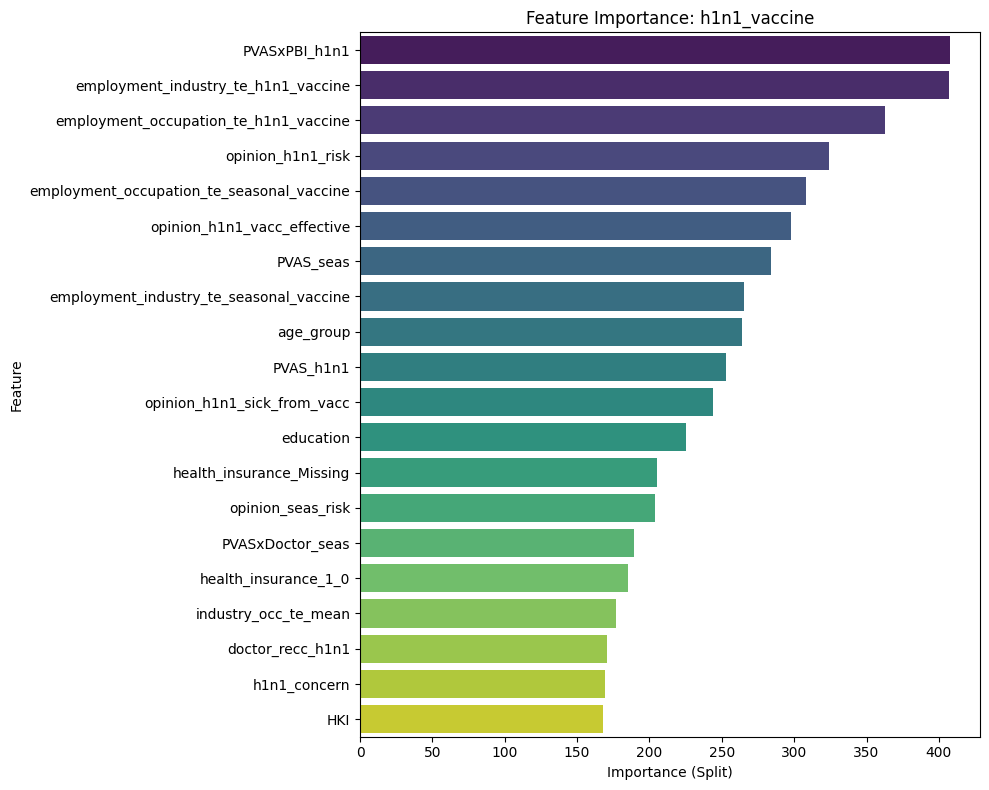


=== Top 10 Features for seasonal_vaccine ===
                                      feature  importance
51      employment_occupation_te_h1n1_vaccine         661
66                              PVASxPBI_h1n1         585
49        employment_industry_te_h1n1_vaccine         582
55                                  PVAS_seas         572
52  employment_occupation_te_seasonal_vaccine         539
50    employment_industry_te_seasonal_vaccine         537
18                          opinion_seas_risk         526
20                                  age_group         500
19                opinion_seas_sick_from_vacc         403
54                                  PVAS_h1n1         394


C:\Users\samak\AppData\Local\Temp\ipykernel_29612\1099630203.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(top_n), x='importance', y='feature', palette='viridis')


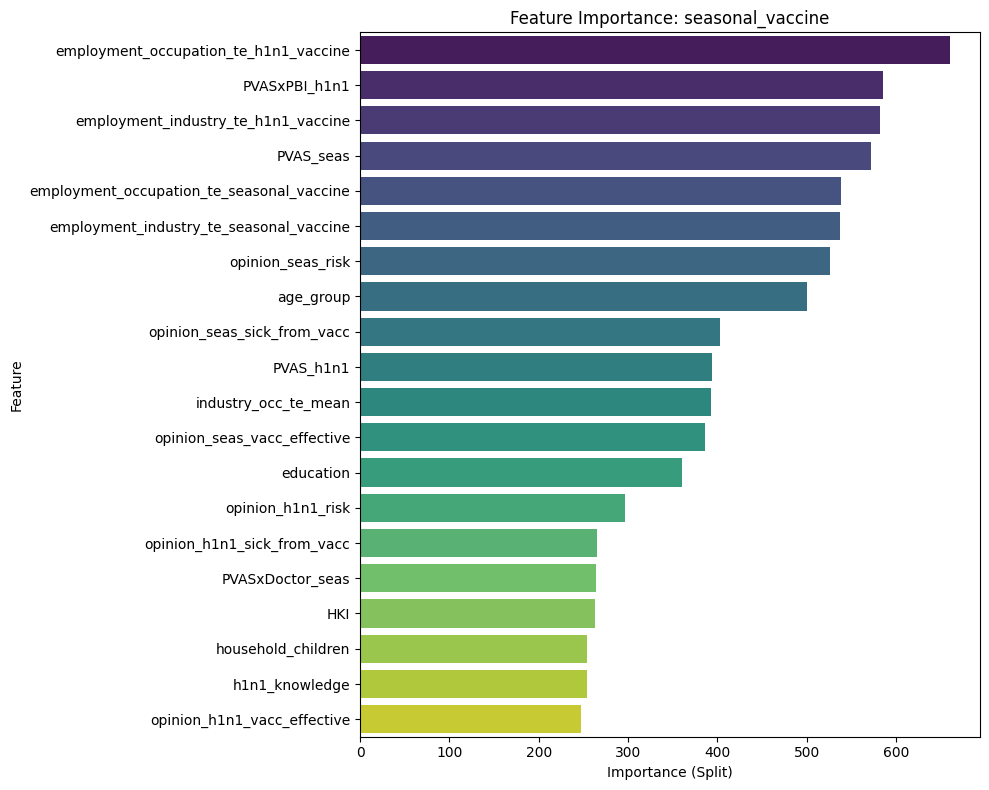

In [11]:
plot_feature_importance(models)

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

def plot_shap_importance(models, X_data):
    """
    Calculates and plots SHAP values for the given models.
    
    Args:
        models: Dictionary of trained models
    """
    # Initialize JS visualization code (if running in a notebook environment)
    shap.initjs()
    
    for target, model in models.items():
        print(f"\n=== SHAP Analysis for {target} ===")
        
        # Create TreeExplainer
        # LightGBM models are tree-based, so TreeExplainer is fast and exact
        explainer = shap.TreeExplainer(model)
        
        # Calculate SHAP values
        shap_values = explainer.shap_values(X_data)
        
        # For binary classification, shap_values is often a list: [class_0_values, class_1_values]
        # We are interested in class 1 (the positive case: received vaccine)
        if isinstance(shap_values, list):
            vals = shap_values[1]
        else:
            vals = shap_values
            
        # 1. Summary Plot (Beeswarm)
        # Shows feature importance ranking AND how feature values impact the output
        plt.figure()
        plt.title(f"SHAP Summary: {target}")
        shap.summary_plot(vals, X_data, show=False)
        plt.tight_layout()
        plt.show()
        
        # 2. Bar Plot (Mean absolute SHAP value)
        # Simpler view, strictly for ranking importance magnitude
        plt.figure()
        plt.title(f"SHAP Feature Importance (Mean Abs): {target}")
        shap.summary_plot(vals, X_data, plot_type="bar", show=False)
        plt.tight_layout()
        plt.show()

# Usage Example:
# ---------------------------------------------------------
# from src.modeling_lgbm import load_final_models, load_training_data
#
# # 1. Load Models
# models = load_final_models()
#
# # 2. Load Data (Need features to calculate SHAP values)
# X, _ = load_training_data("data/training_set_features.csv", "data/training_set_labels.csv")
#
# # 3. Sample data for speed (calculating SHAP on full dataset can be slow)
# X_sample = X.sample(n=2000, random_state=42)
#
# # 4. Run
# plot_shap_importance(models, X_sample)

c:\Projects\Redi\NeuroShot_v.2\neuro_flushot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
from src.modeling_lgbm import load_final_models, load_training_data

# # 1. Load Models
# models = load_final_models()

In [ ]:
# # 2. Load Data (Need features to calculate SHAP values)
X, _ = load_training_data(DATA_TRAIN, DATA_LABELS)

In [16]:
# # 3. Sample data for speed (calculating SHAP on full dataset can be slow)
X_sample = X.sample(n=2000, random_state=42)


=== SHAP Analysis for h1n1_vaccine ===


c:\Projects\Redi\NeuroShot_v.2\neuro_flushot\.venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


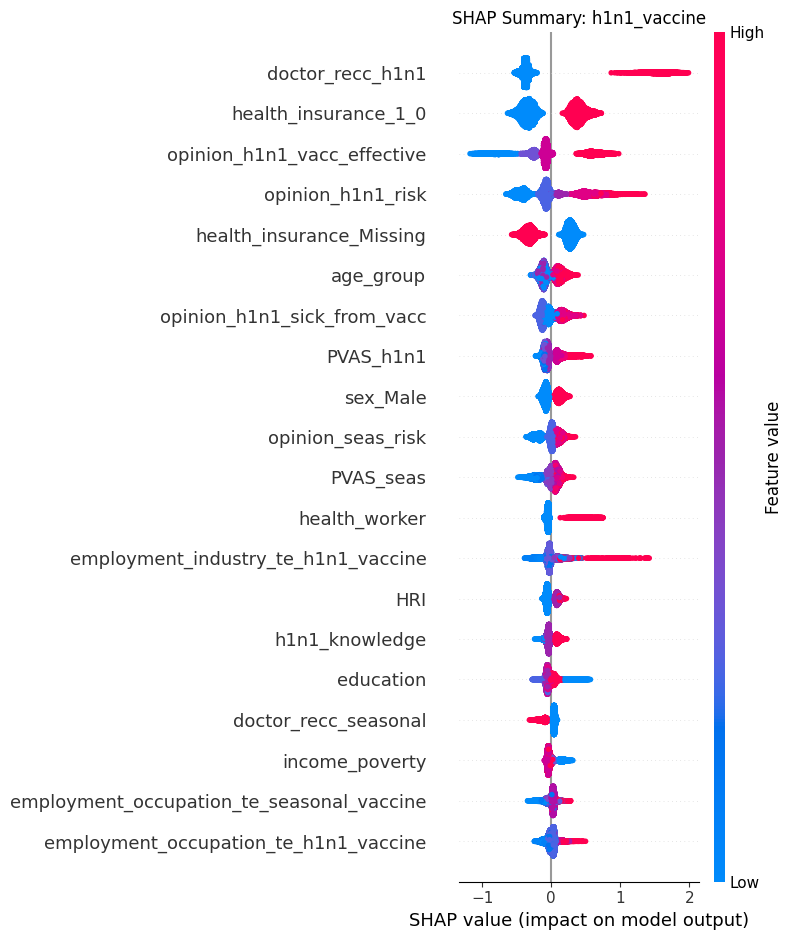

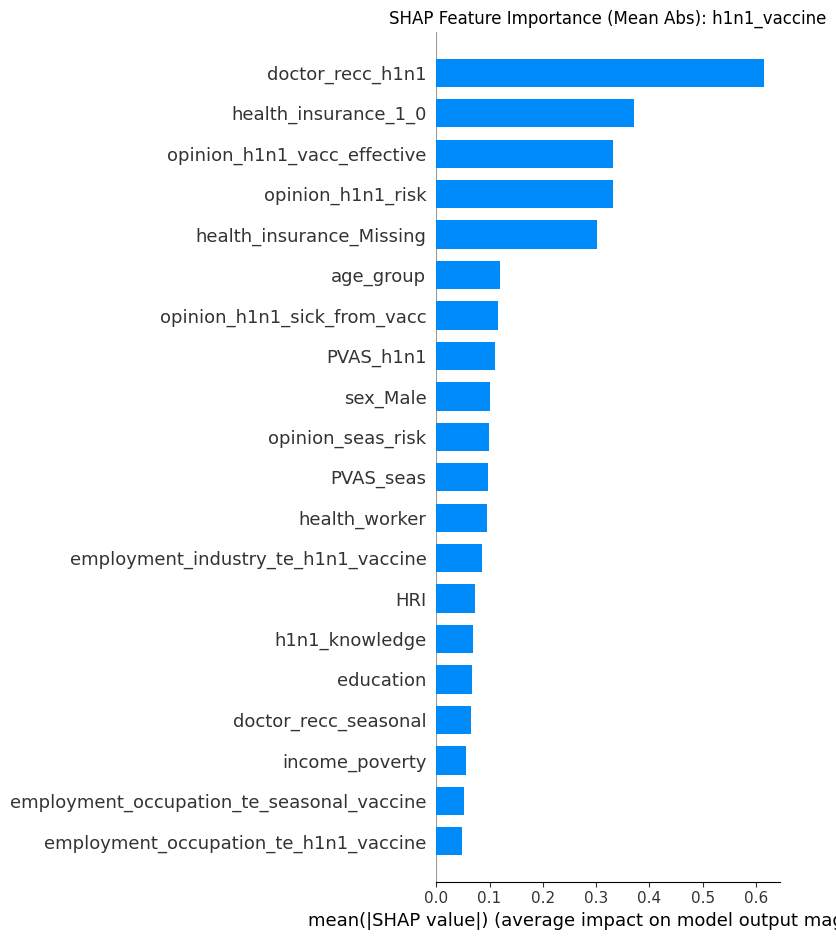


=== SHAP Analysis for seasonal_vaccine ===


c:\Projects\Redi\NeuroShot_v.2\neuro_flushot\.venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


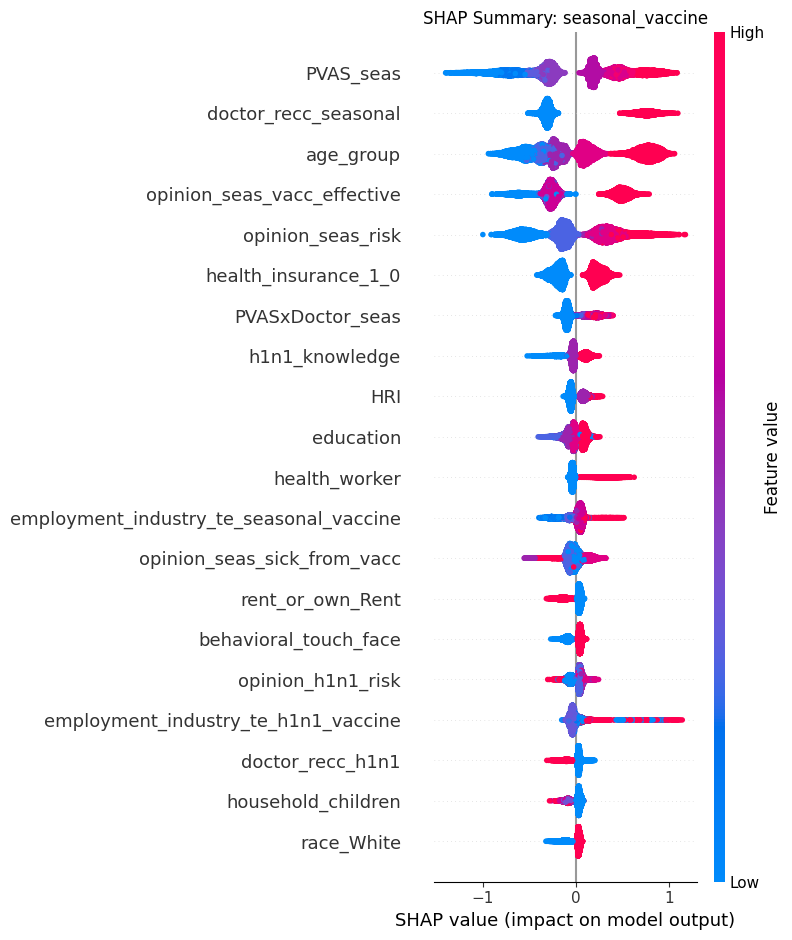

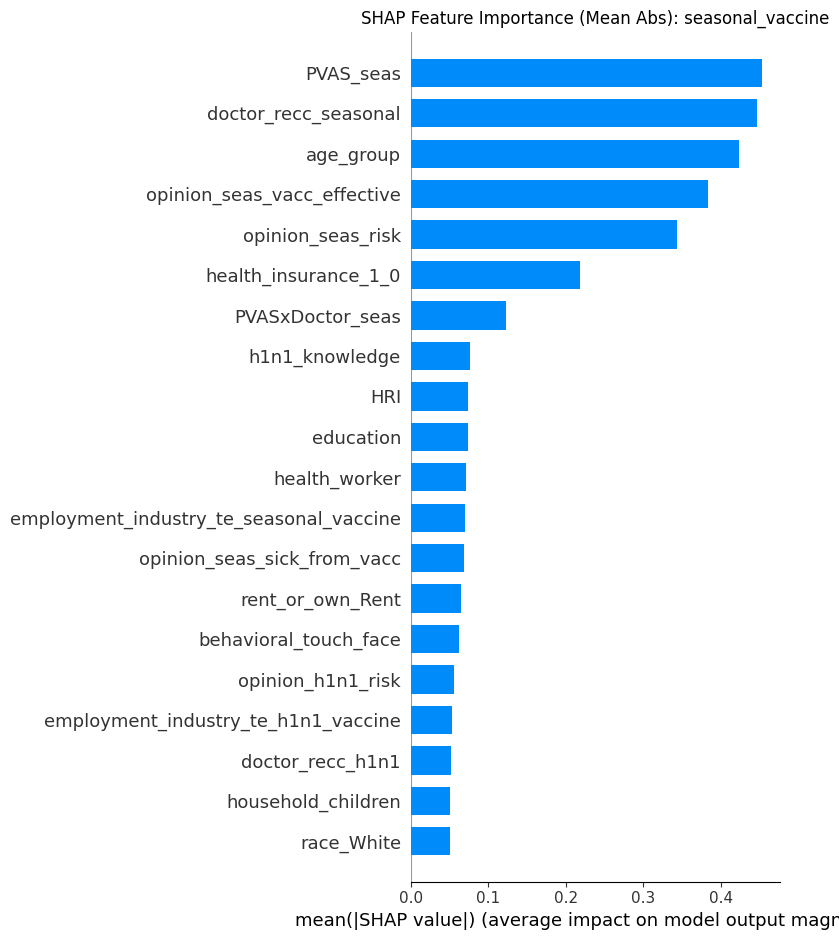

In [18]:
# # 4. Run
plot_shap_importance(models, X)